In [140]:
import pandas as pd
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sys.path.append(r"D:/Football Project/src")

import feature_lists as fl

In [141]:
df=pd.read_csv('../../../data/processed/major_leagues/EWMA_Major_Leagues.csv')

In [142]:
df=df[df['position']=='Midfielders']

In [143]:
df=df.drop(columns=fl.goalkeeper_features_z)

In [144]:
df=df.drop(columns=fl.discipline_features_z)

In [145]:
df=df.drop(columns=[
    'rating_zscore',
    'countrating_zscore',
    'totalrating_zscore',
])

In [146]:
existing_cols_to_drop = [col for col in fl.volume_zscore_cols if col in df.columns]
df = df.drop(columns=existing_cols_to_drop)

In [147]:
df.shape

(1895, 96)

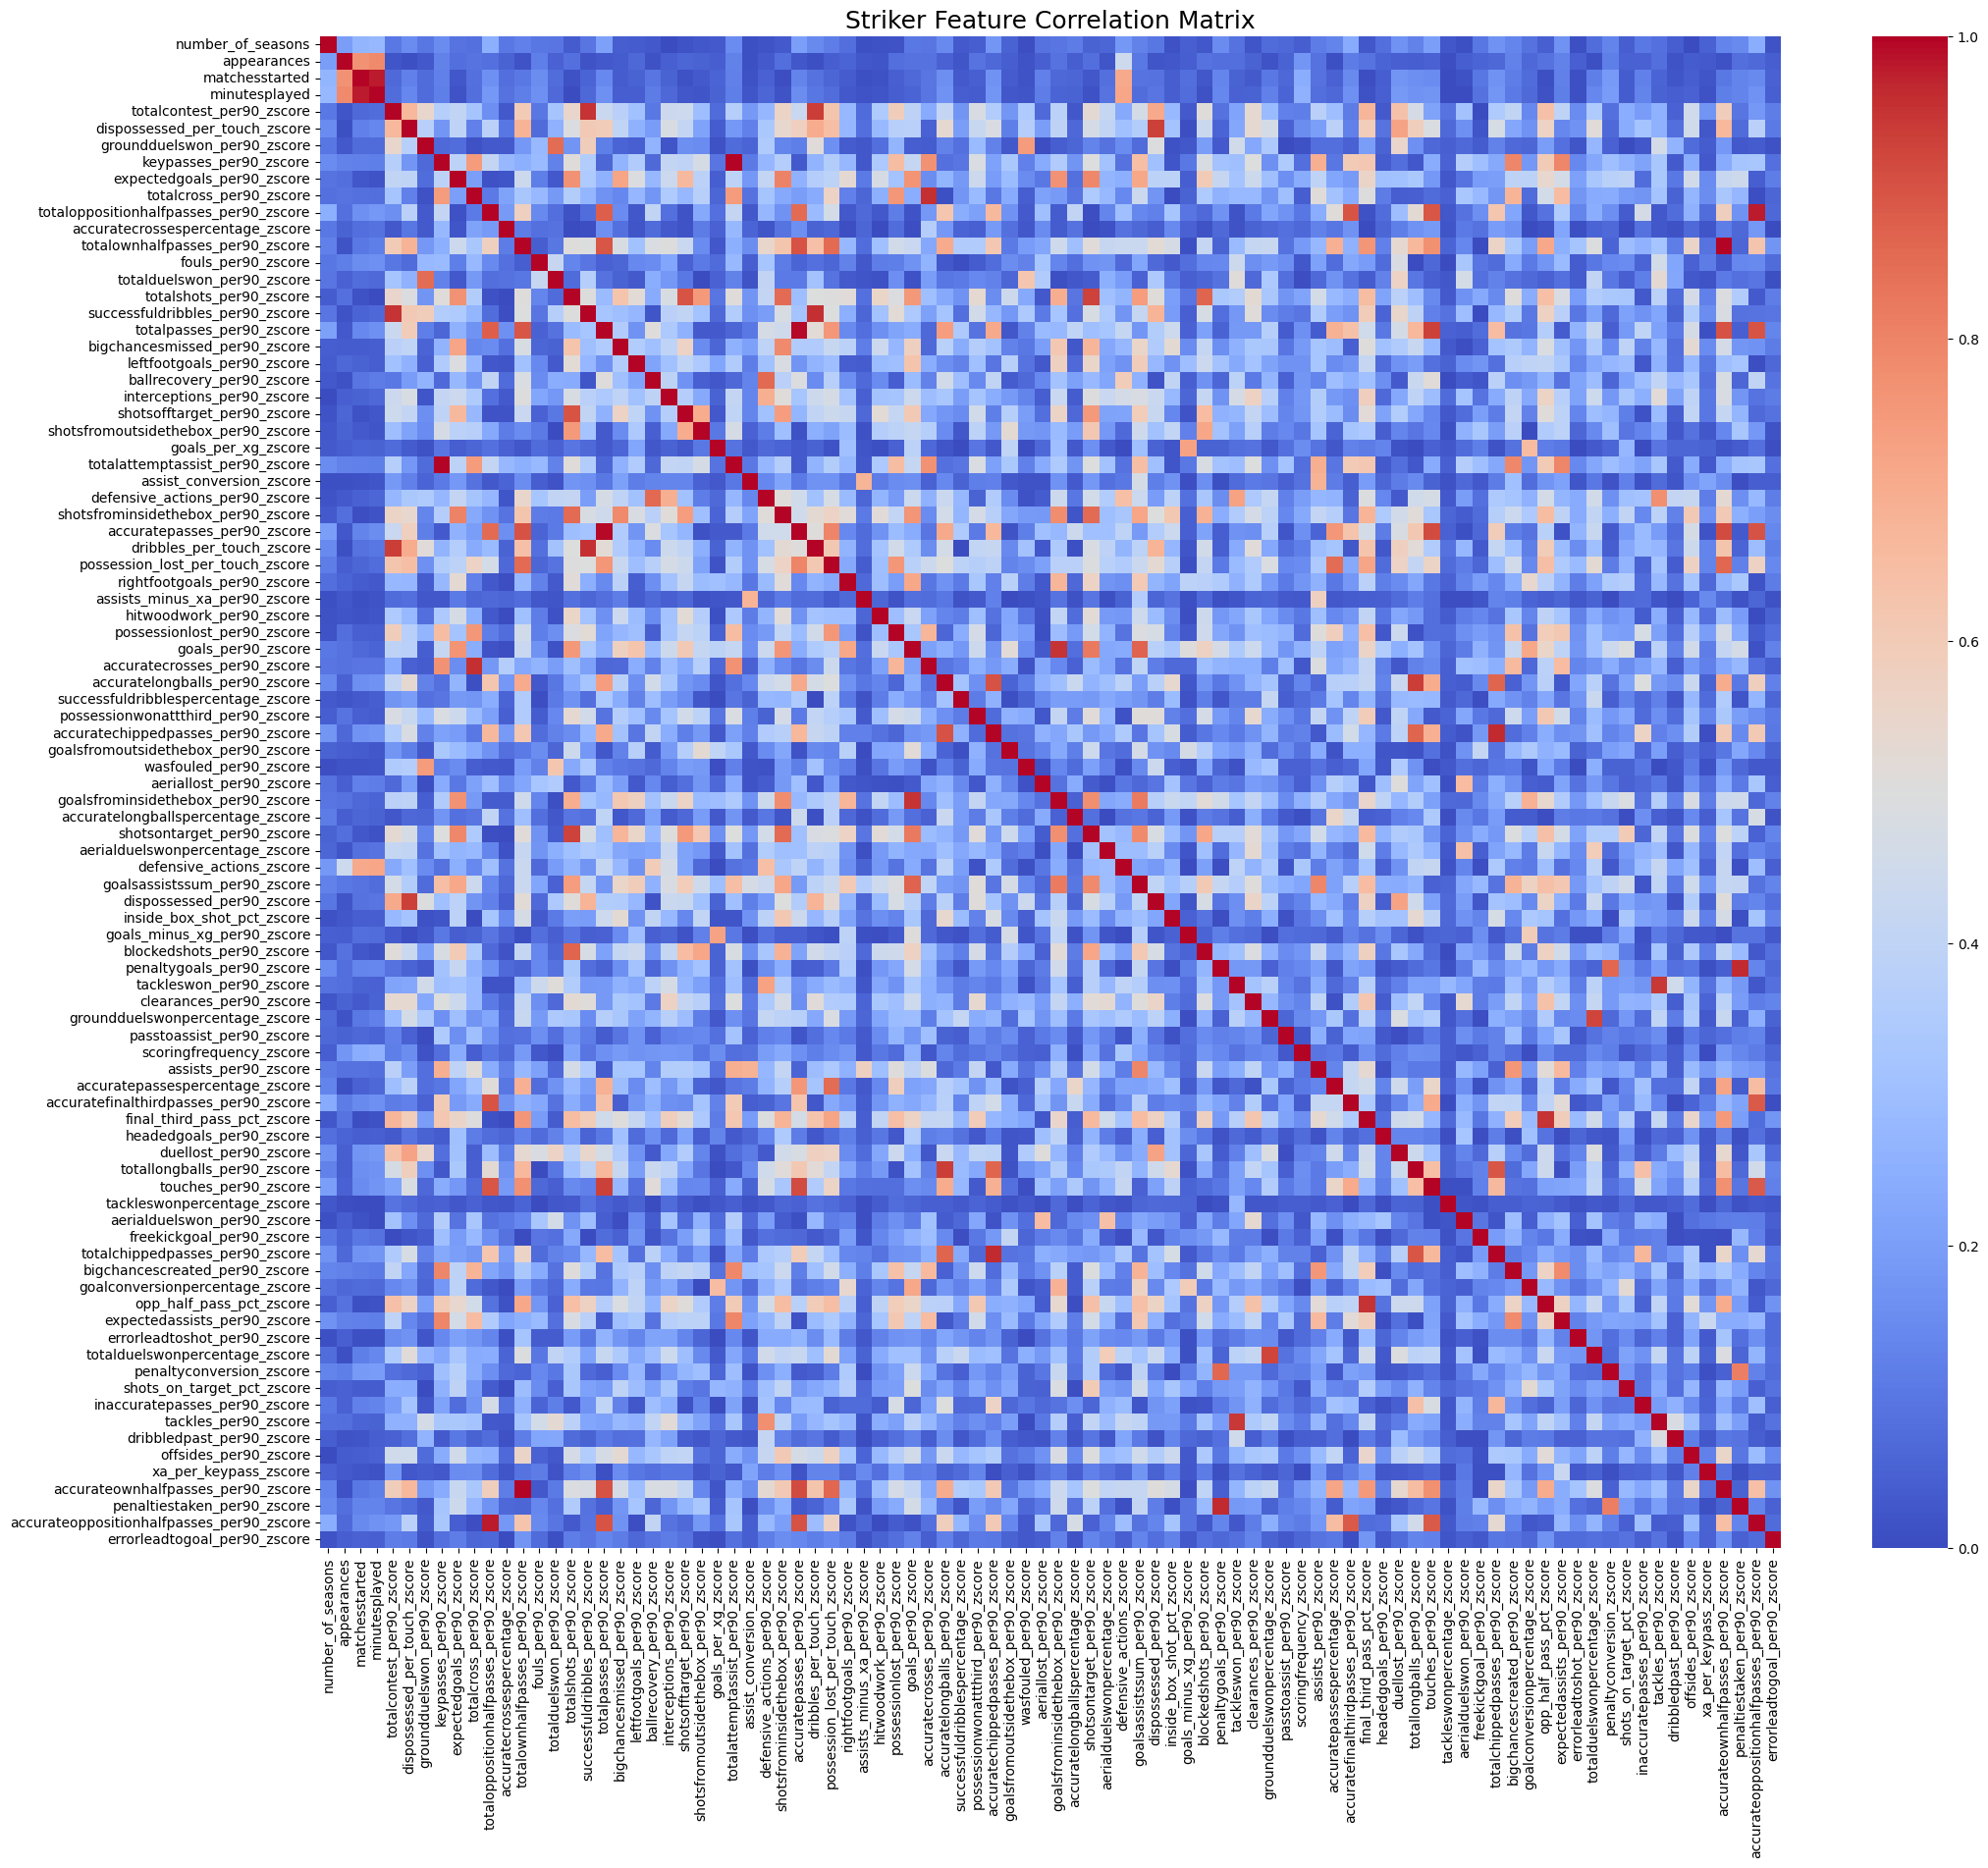

In [148]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [149]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,keypasses_per90_zscore,totalattemptassist_per90_zscore,0.999300
1,totalownhalfpasses_per90_zscore,accurateownhalfpasses_per90_zscore,0.997790
2,totalpasses_per90_zscore,accuratepasses_per90_zscore,0.992604
3,totaloppositionhalfpasses_per90_zscore,accurateoppositionhalfpasses_per90_zscore,0.977923
4,matchesstarted,minutesplayed,0.976734
5,penaltygoals_per90_zscore,penaltiestaken_per90_zscore,0.963616
6,accuratechippedpasses_per90_zscore,totalchippedpasses_per90_zscore,0.963002
7,totalcross_per90_zscore,accuratecrosses_per90_zscore,0.955916
8,successfuldribbles_per90_zscore,dribbles_per_touch_zscore,0.955076
9,final_third_pass_pct_zscore,opp_half_pass_pct_zscore,0.950201


In [150]:
df=df.drop(columns=[
    'totalattemptassist_per90_zscore','totalownhalfpasses_per90_zscore',
    'totalpasses_per90_zscore','totaloppositionhalfpasses_per90_zscore',
    'totalchippedpasses_per90_zscore','accuratechippedpasses_per90_zscore',
    'totalcross_per90_zscore','goalsassistssum_per90_zscore',
    'penaltiestaken_per90_zscore','dribbles_per_touch_zscore','totalcontest_per90_zscore',
    'tackles_per90_zscore','accuratepasses_per90_zscore','goalsfrominsidethebox_per90_zscore',
    'totallongballs_per90_zscore','opp_half_pass_pct_zscore','accurateoppositionhalfpasses_per90_zscore',
    'accurateownhalfpasses_per90_zscore','accuratepassespercentage_zscore','totalshots_per90_zscore',
    'shotsofftarget_per90_zscore','shotsfrominsidethebox_per90_zscore','dispossessed_per90_zscore',
    'penaltygoals_per90_zscore','defensive_actions_per90_zscore','totalduelswonpercentage_zscore',
    'totalduelswon_per90_zscore'
    ])

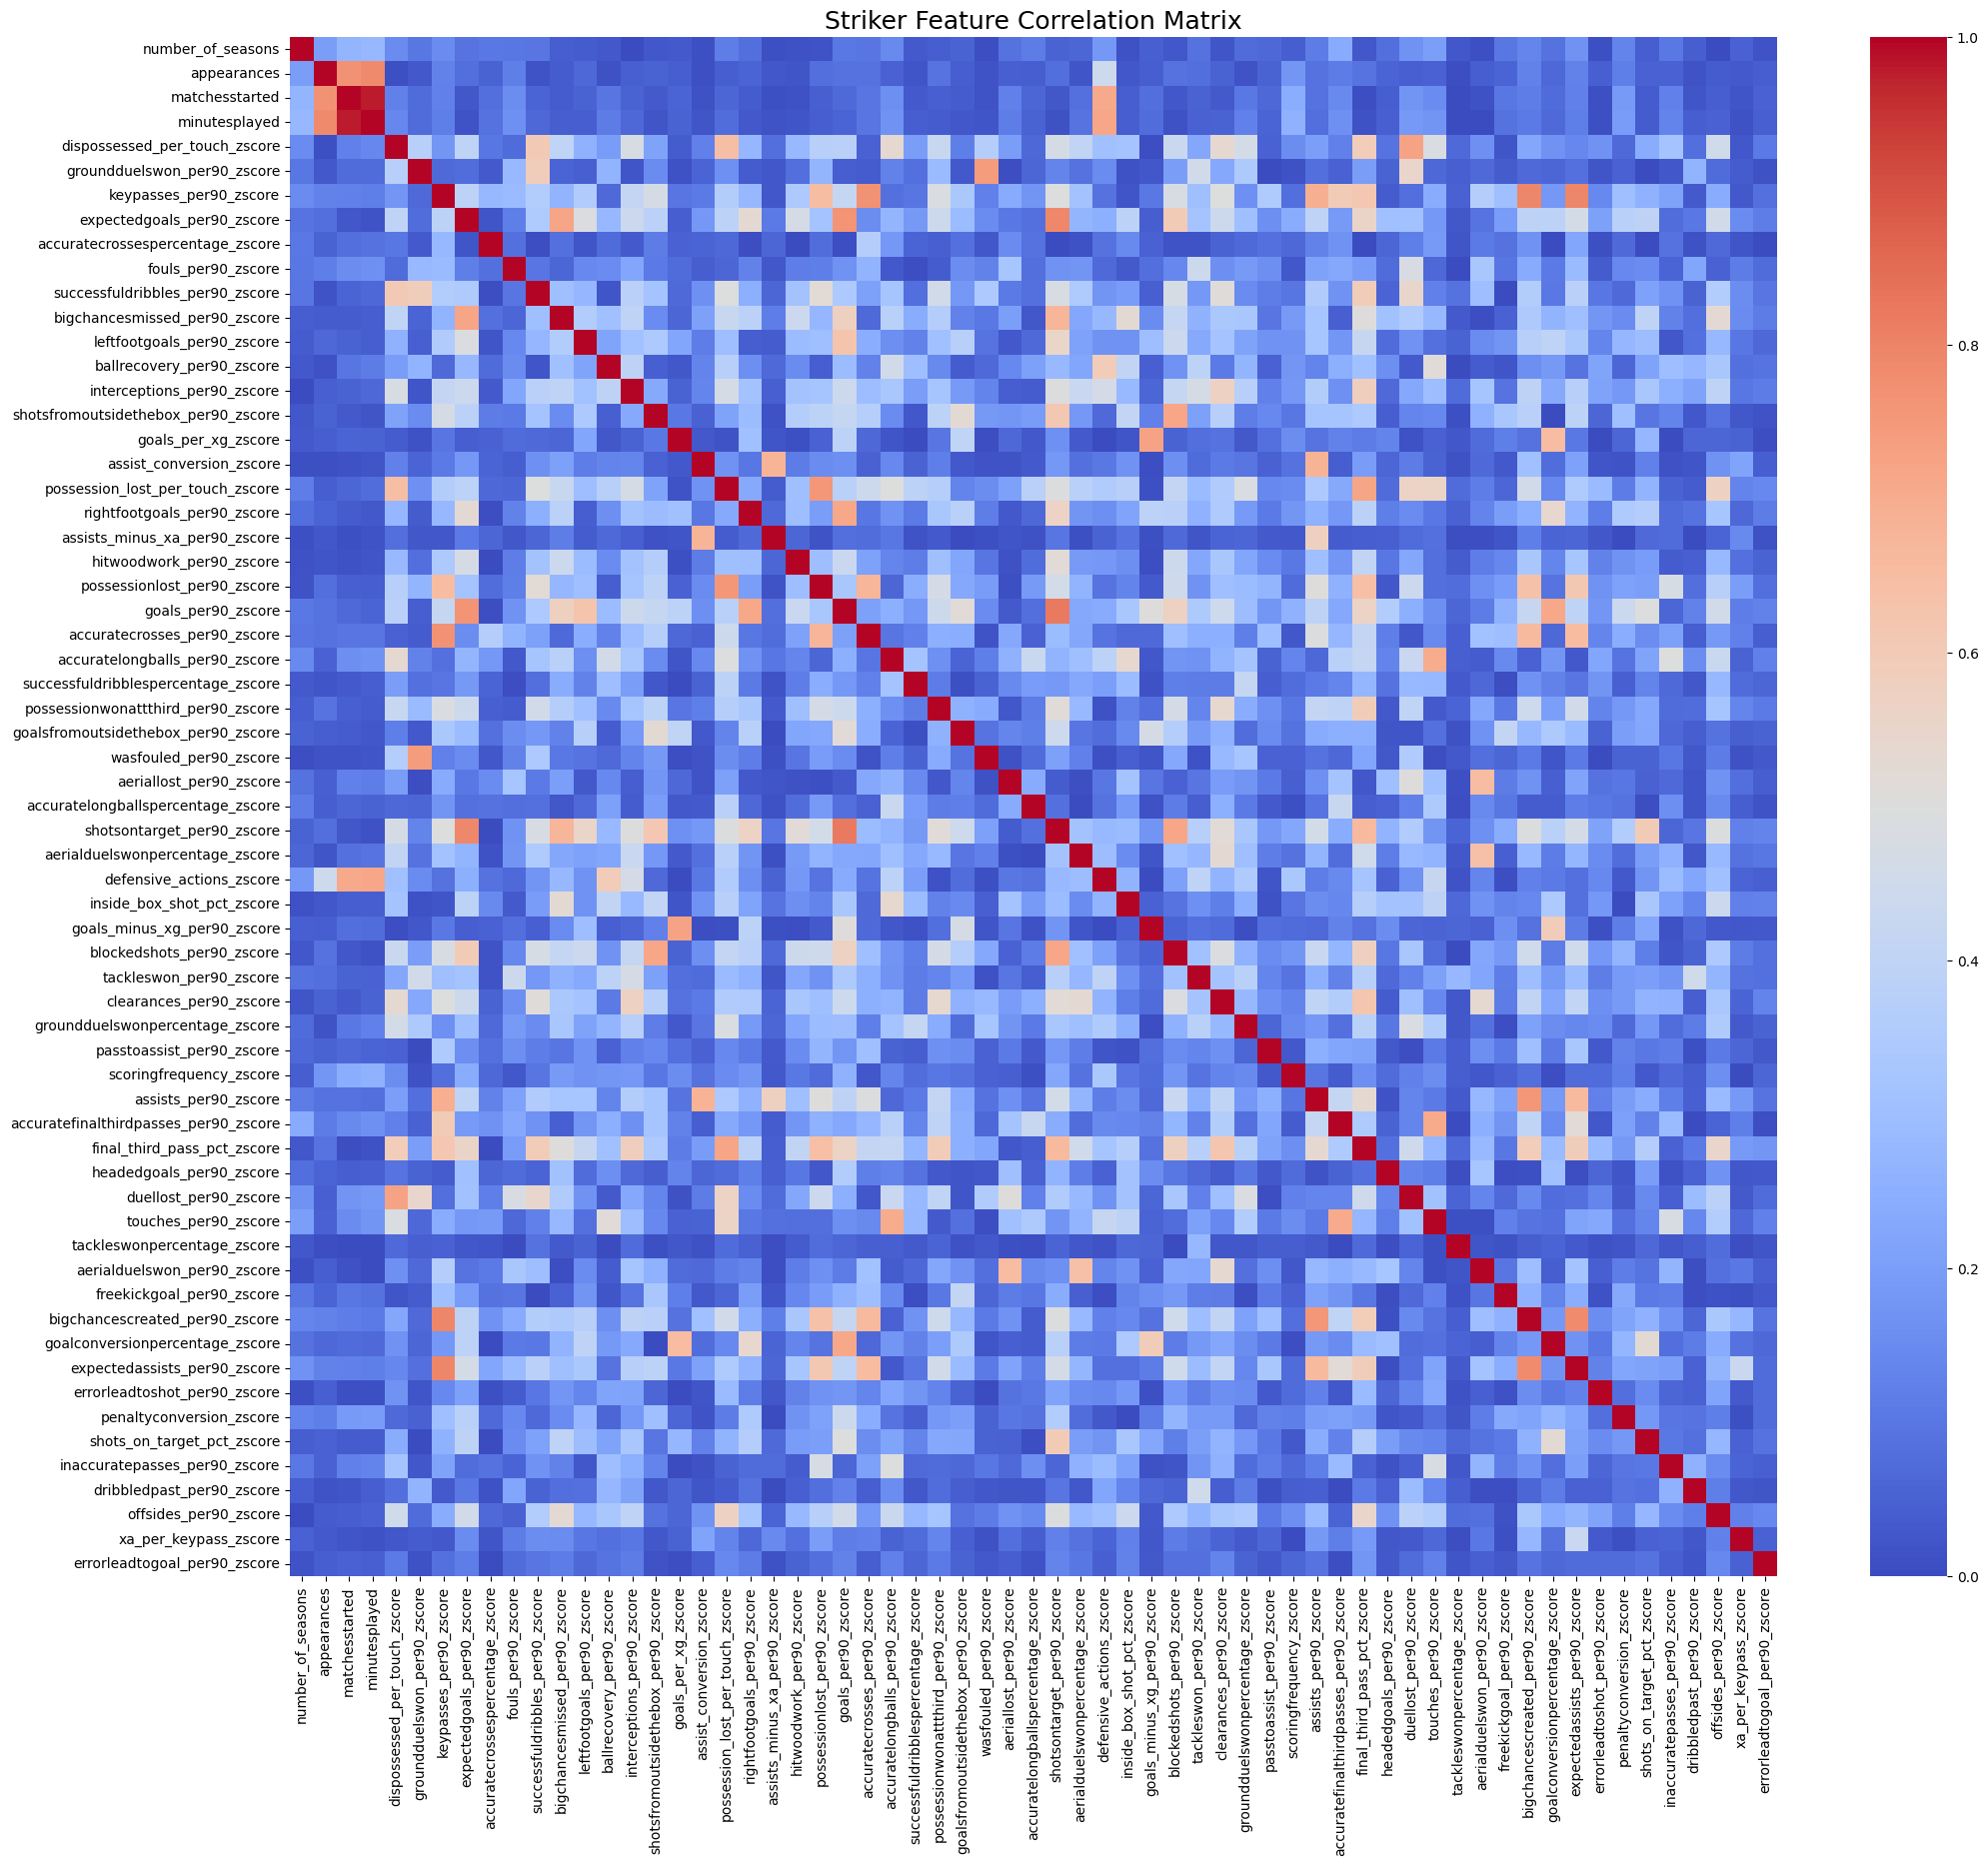

In [151]:
corr_matrix = df.drop(columns=fl.metadata_features).corr().abs()

plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False, vmin=0, vmax=1)
plt.title("Striker Feature Correlation Matrix", fontsize=18)
plt.show()

In [152]:
corr_pairs = corr_matrix.unstack()
high_corr = corr_pairs[(corr_pairs > 0.80) & (corr_pairs < 1.0)].drop_duplicates().sort_values(ascending=False)

high_corr_df = pd.DataFrame(high_corr).reset_index()
high_corr_df.columns = ['Feature_1', 'Feature_2', 'Correlation']

with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(high_corr_df)

,Feature_1,Feature_2,Correlation
0,matchesstarted,minutesplayed,0.976734
1,goals_per90_zscore,shotsontarget_per90_zscore,0.822541


In [153]:
df.shape

(1895, 69)

In [154]:
df.columns.to_list()

['player id',
 'player',
 'team id',
 'team',
 'league',
 'position',
 'number_of_seasons',
 'appearances',
 'matchesstarted',
 'minutesplayed',
 'dispossessed_per_touch_zscore',
 'groundduelswon_per90_zscore',
 'keypasses_per90_zscore',
 'expectedgoals_per90_zscore',
 'accuratecrossespercentage_zscore',
 'fouls_per90_zscore',
 'successfuldribbles_per90_zscore',
 'bigchancesmissed_per90_zscore',
 'leftfootgoals_per90_zscore',
 'ballrecovery_per90_zscore',
 'interceptions_per90_zscore',
 'shotsfromoutsidethebox_per90_zscore',
 'goals_per_xg_zscore',
 'assist_conversion_zscore',
 'possession_lost_per_touch_zscore',
 'rightfootgoals_per90_zscore',
 'assists_minus_xa_per90_zscore',
 'hitwoodwork_per90_zscore',
 'possessionlost_per90_zscore',
 'goals_per90_zscore',
 'accuratecrosses_per90_zscore',
 'accuratelongballs_per90_zscore',
 'successfuldribblespercentage_zscore',
 'possessionwonattthird_per90_zscore',
 'goalsfromoutsidethebox_per90_zscore',
 'wasfouled_per90_zscore',
 'aeriallost_pe

In [155]:
df.to_csv('../../../data/processed/major_leagues/Midfielders/EWMA_Major_Midfielders.csv',index=False)